## 1. Câu hỏi nghiên cứu
**Câu hỏi:** "Làm thế nào để xác định các khu vực (Quận/Phường) là 'vùng trũng giá trị' - nơi người thuê nhận được lợi ích tối đa (diện tích, tiện nghi, an ninh) với mức chi phí thấp nhất, và đâu là những khu vực đang bị 'thổi giá' (overpriced)?"

**Tính xác thực:** Câu hỏi này có thể trả lời trực tiếp bằng dữ liệu thông qua việc xây dựng một chỉ số tổng hợp (Cost Efficiency Index) từ các biến định lượng có sẵn trong tập dữ liệu như `price`, `area`, `amenity_score`, và `security_score`.

## 2. Động cơ & Lợi ích
* **Vì sao đáng nghiên cứu?** Việc chỉ nhìn vào giá thuê thấp thường dẫn đến sai lầm vì bỏ qua chất lượng sống. Phân tích này giúp định nghĩa lại khái niệm "rẻ" sang "đáng tiền".
* **Lợi ích & Insight:** Xác định được các "viên ngọc ẩn" của thị trường - những phòng trọ có hiệu suất sử dụng trên giá thành cực cao mà người dùng thường bỏ lỡ nếu chỉ lọc theo giá.
* **Đối tượng quan tâm:** * **Sinh viên & Người lao động:** Tìm được nơi ở tốt nhất trong ngân sách hạn hẹp.
    * **Nhà đầu tư/Chủ trọ:** Hiểu được vị thế cạnh tranh của mình để điều chỉnh tiện ích hoặc giá thuê.
* **Hỗ trợ thực tế:** Giúp sinh viên trả lời câu hỏi: "Với 5 triệu đồng, tôi nên thuê ở Quận 10 hay Quận 7 để có lợi ích cao hơn?"

## 3. Phân tích dữ liệu

### A. Tiền xử lý dữ liệu
**Quy trình thực hiện:**
1. **Chuẩn hóa thang đo (Scaling):** Do `area` (m2), `security_score` (1-5), và `amenity_score` (0-10) có đơn vị khác nhau, chúng ta sử dụng `MinMaxScaler` để đưa tất cả về thang [0, 1]. Điều này đảm bảo các biến có vai trò công bằng khi tính toán.
2. **Xây dựng Điểm lợi ích (Benefit Score):** Áp dụng trọng số dựa trên tư duy thực tế:
    * **Diện tích (0.5):** Ưu tiên hàng đầu vì sinh viên thường ở ghép.
    * **Tiện nghi (0.3):** Nội thất ảnh hưởng trực tiếp đến sinh hoạt.
    * **An ninh (0.2):** Yếu tố quan trọng nhưng thường có sự tương đồng ở các phân khúc.
3. **Tính toán Chỉ số Hiệu quả Chi phí (CEI):** CEI = Benefit Score / Price (đã chuẩn hóa). Chúng ta thêm một số $\epsilon$ (epsilon) nhỏ vào mẫu số để tránh lỗi chia cho 0 và làm mượt dữ liệu ở vùng giá cực thấp.

**Lý do:** Logic này giúp cô lập tác động của từng đồng tiền bỏ ra so với giá trị nhận lại, biến các con số rời rạc thành một thước đo thống nhất.

In [3]:
# Cài đặt Tiền xử lý dữ liệu
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Tải dữ liệu từ đường dẫn đã chỉ định
df = pd.read_csv("../../data/processed/data_clean.csv")

# 2. Khởi tạo MinMaxScaler để chuẩn hóa dữ liệu về thang [0, 1]
scaler = MinMaxScaler()
cols_to_norm = ['area', 'amenity_score', 'security_score', 'price']

# Tạo bản sao để tránh thay đổi dữ liệu gốc
df_analysis = df.copy()
norm_cols = [f'{c}_norm' for c in cols_to_norm]
df_analysis[norm_cols] = scaler.fit_transform(df_analysis[cols_to_norm])

# 3. Tính toán Benefit Score với trọng số (Weights)
# w_area=0.5, w_ame=0.3, w_sec=0.2
df_analysis['benefit_score'] = (
    df_analysis['area_norm'] * 0.5 + 
    df_analysis['amenity_score_norm'] * 0.3 + 
    df_analysis['security_score_norm'] * 0.2
)

# 4. Tính toán Cost Efficiency Index (CEI)
# Thêm 0.05 vào price_norm để ổn định chỉ số cho các phòng giá quá rẻ
df_analysis['CEI'] = df_analysis['benefit_score'] / (df_analysis['price_norm'] + 0.05)

print(f"Hoàn thành tiền xử lý cho {len(df_analysis)} bản ghi.")

Hoàn thành tiền xử lý cho 28554 bản ghi.


### B. Phân tích
**Các phương pháp sử dụng:**
1. **Phân tích Bốn vùng (Quadrant Analysis):** Sử dụng biểu đồ phân tán (Scatter Plot) giữa Giá thuê và Điểm lợi ích để phân loại thị trường dựa trên đường Trung vị (Median). Phương pháp này giúp cô lập nhóm "Ngọc ẩn" (Gems) - lợi ích cao nhưng giá thấp.
2. **Xếp hạng Địa lý (Spatial Aggregation):** Gom nhóm chỉ số CEI theo Quận để nhận diện các "vùng trũng" có hiệu suất giá tốt nhất cũng như tệ nhất
3. **Kiểm định Thống kê (Kruskal-Wallis Test):** Do giá nhà và chỉ số CEI thường có phân phối lệch (không chuẩn), chúng ta sử dụng kiểm định phi tham số Kruskal-Wallis để xác nhận xem sự khác biệt về hiệu quả chi phí giữa các Quận là có ý nghĩa thống kê hay chỉ do ngẫu nhiên.
4. **Phân tích Nhân tố Nội tại :** So sánh chỉ số CEI giữa nhóm phòng có gác lửng và không gác cũng như nhóm full nội thất và không có nội thất để kiểm chứng xem yếu tố nào ảnh hưởng giá trị thực tế của căn hộ.

**Lý do chọn:** Sự kết hợp giữa trực quan hóa và kiểm định thống kê giúp đảm bảo các kết luận rút ra có độ tin cậy cao và giải thích được bản chất của thị trường.

#### B.1. Phân tích Ma trận Bốn vùng (Quadrant Analysis)
Bước này giúp chúng ta phân loại toàn bộ các căn phòng trong tập dữ liệu vào 4 nhóm dựa trên đường trung vị (Median) của **Giá thuê** và **Điểm lợi ích**. 
* **Mục tiêu:** Nhận diện chính xác nhóm nhà trọ với mức giá hời nằm ở góc trên bên trái - nơi giá thấp nhưng chất lượng vượt trội.

c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\DELL\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


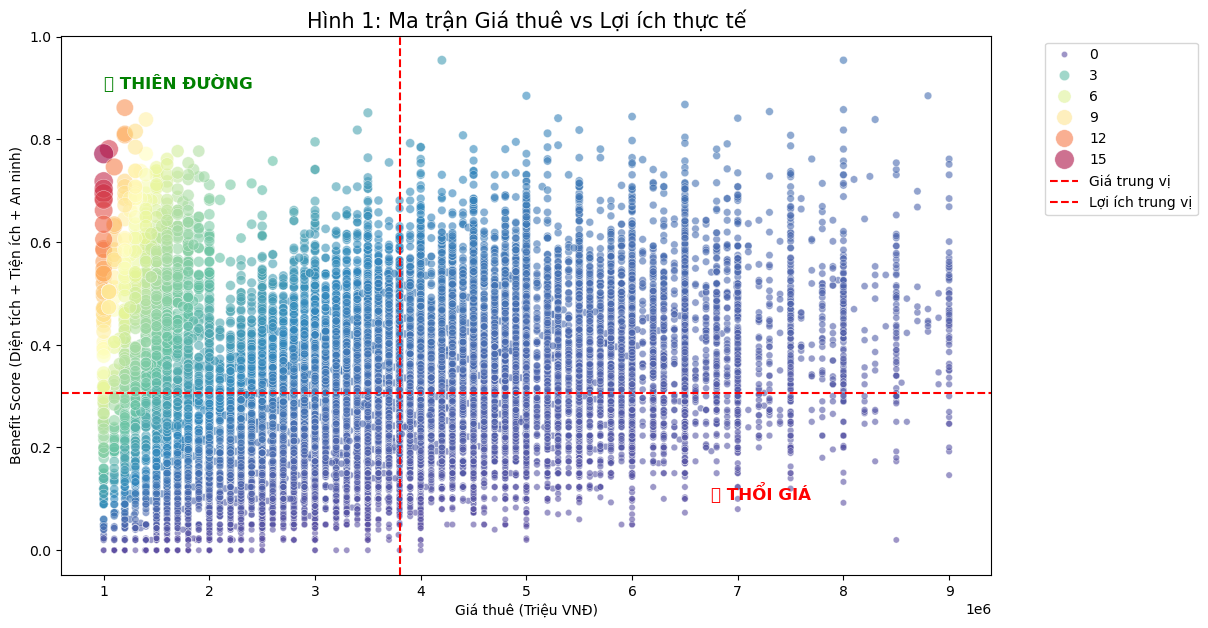

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Tính toán trung vị để phân vùng Quadrant
median_p = df_analysis['price'].median()
median_b = df_analysis['benefit_score'].median()

# 2. Vẽ biểu đồ Quadrant Analysis
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_analysis, x='price', y='benefit_score', 
                hue='CEI', palette='Spectral_r', alpha=0.6, size='CEI', sizes=(20, 200))

# Kẻ các đường phân cách vùng dựa trên trung vị
plt.axvline(median_p, color='red', linestyle='--', label='Giá trung vị')
plt.axhline(median_b, color='red', linestyle='--', label='Lợi ích trung vị')

# Thêm nhãn hướng dẫn cho các vùng
plt.text(df_analysis['price'].min(), 0.9, "💎 THIÊN ĐƯỜNG ", color='green', fontweight='bold', fontsize=12)
plt.text(df_analysis['price'].max()*0.75, 0.1, "❌ THỔI GIÁ ", color='red', fontweight='bold', fontsize=12)

plt.title('Hình 1: Ma trận Giá thuê vs Lợi ích thực tế', fontsize=15)
plt.xlabel('Giá thuê (Triệu VNĐ)')
plt.ylabel('Benefit Score (Diện tích + Tiện ích + An ninh)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### B.2. Xếp hạng "Vùng trũng giá trị" theo Quận/Huyện
Chúng ta tiến hành gom nhóm dữ liệu theo vị trí địa lý để tìm ra những khu vực có chỉ số **CEI trung bình** cao nhất. Điều này giúp xác định các "thiên đường" thực tế cho người thuê.

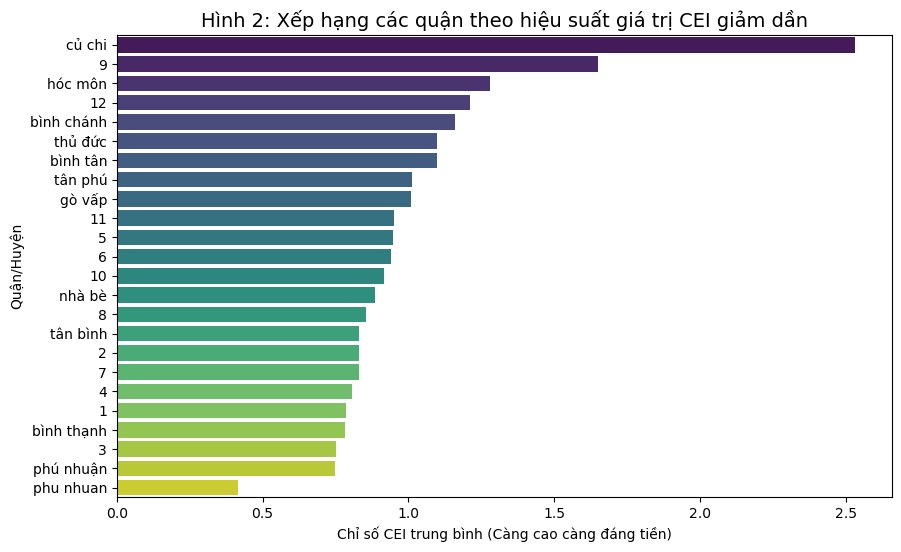

In [5]:
# Tính CEI trung bình cho từng Quận và lấy Top 10
top_10_districts = df_analysis.groupby('district')['CEI'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_districts.values, y=top_10_districts.index, hue=top_10_districts.index, palette='viridis')

plt.title('Hình 2: Xếp hạng các quận theo hiệu suất giá trị CEI giảm dần', fontsize=14)
plt.xlabel('Chỉ số CEI trung bình (Càng cao càng đáng tiền)')
plt.ylabel('Quận/Huyện')
plt.show()

#### B.3. Kiểm định ý nghĩa thống kê (Kruskal-Wallis Test)
Để đảm bảo sự khác biệt về CEI giữa các quận không phải do ngẫu nhiên, chúng ta sử dụng kiểm định phi tham số Kruskal-Wallis. 
* **Lý do chọn:** Chỉ số CEI thường có phân phối lệch (không chuẩn), vì vậy kiểm định phi tham số sẽ mang lại kết quả tin cậy hơn ANOVA.

In [6]:
from scipy.stats import kruskal

# Chuẩn bị các nhóm dữ liệu CEI theo Quận
groups = [group['CEI'].values for name, group in df_analysis.groupby('district')]

# Thực hiện kiểm định Kruskal-Wallis
h_stat, p_val = kruskal(*groups)

print(f"--- KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS ---")
print(f"H-statistic: {h_stat:.2f}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("=> Kết luận: Có sự khác biệt có ý nghĩa thống kê về hiệu quả chi phí (CEI) giữa các Quận.")
else:
    print("=> Kết luận: Không đủ bằng chứng cho thấy sự khác biệt về CEI giữa các khu vực.")

--- KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS ---
H-statistic: 2856.80
p-value: 0.0000
=> Kết luận: Có sự khác biệt có ý nghĩa thống kê về hiệu quả chi phí (CEI) giữa các Quận.


#### B.4. Phân tích so sánh các Nhân tố chiến lược (Duplex vs Full Furniture)
Trong phần này, chúng ta sẽ so sánh hai "vũ khí" mạnh nhất có thể tối ưu hóa chỉ số CEI:
1. **Thiết kế Gác lửng (`is_duplex`):** Tối ưu hóa về mặt không gian 
2. **Nội thất đầy đủ (`is_full_furniture`):** Tối ưu hóa về mặt chi phí đầu tư ban đầu 

**Mục tiêu:** Xác định nhân tố nào có sức ảnh hưởng lớn hơn đến hiệu quả chi phí và liệu sự kết hợp của cả hai có tạo ra những căn phòng "vô đối" về giá trị hay không.

C:\Users\DELL\AppData\Local\Temp\ipykernel_18252\815626589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_duplex', y='CEI', palette='Set2', ax=axes[0])
C:\Users\DELL\AppData\Local\Temp\ipykernel_18252\815626589.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_full_furniture', y='CEI', palette='Pastel1', ax=axes[1])


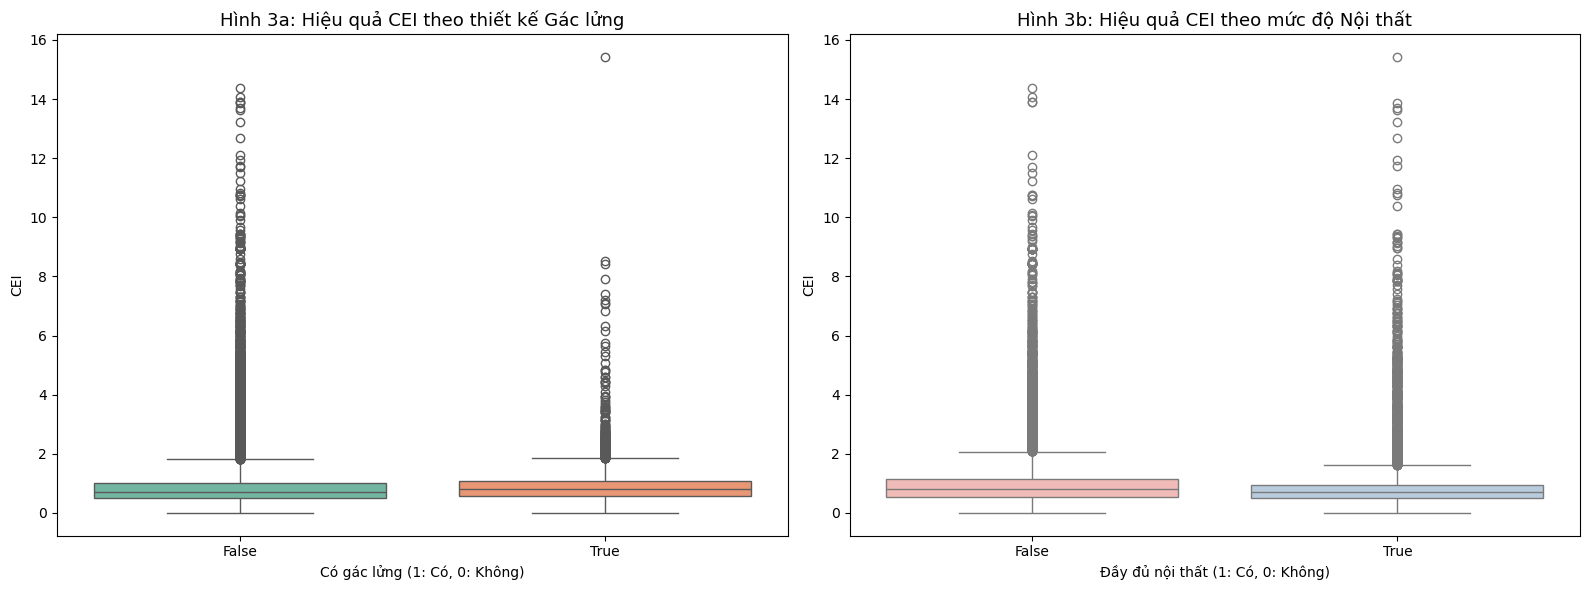

--- Trung vị CEI theo cặp nhân tố ---
is_full_furniture     False     True 
is_duplex                            
False              0.768004  0.686500
True               0.834758  0.768298


In [7]:
# Tạo khung hình với 2 biểu đồ con để so sánh trực diện
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. So sánh CEI theo Gác lửng
sns.boxplot(data=df_analysis, x='is_duplex', y='CEI', palette='Set2', ax=axes[0])
axes[0].set_title('Hình 3a: Hiệu quả CEI theo thiết kế Gác lửng', fontsize=13)
axes[0].set_xlabel('Có gác lửng (1: Có, 0: Không)')

# 2. So sánh CEI theo Nội thất
sns.boxplot(data=df_analysis, x='is_full_furniture', y='CEI', palette='Pastel1', ax=axes[1])
axes[1].set_title('Hình 3b: Hiệu quả CEI theo mức độ Nội thất', fontsize=13)
axes[1].set_xlabel('Đầy đủ nội thất (1: Có, 0: Không)')

plt.tight_layout()
plt.show()


# Thống kê mô tả để lấy số liệu diễn giải
stats = df_analysis.groupby(['is_duplex', 'is_full_furniture'])['CEI'].median().unstack()
print("--- Trung vị CEI theo cặp nhân tố ---")
print(stats)

## C. KẾT QUẢ VÀ DIỄN GIẢI

### 4.1. Trả lời câu hỏi nghiên cứu
* **Bản đồ giá trị (Hình 1):** Nhóm "Gems" tập trung ở góc trên-trái: lợi ích > ~0.3 nhưng giá < ~3.8 triệu. Nhiều điểm "thổi giá" nằm dưới đường lợi ích trung vị ở vùng giá cao (> ~6 triệu).
* **Vùng trũng giá trị theo địa lý (Hình 2):** CEI trung bình cao nhất lần lượt thuộc về **Củ Chi**, **Quận 9**, **Hóc Môn**, **Quận 12**, **Bình Chánh**, **Thủ Đức**, **Bình Tân**, **Tân Phú**, **Gò Vấp**. Các quận trung tâm như **Phú Nhuận** và **Quận 1** nằm cuối bảng xếp hạng (CEI thấp nhất).

### 4.2. Các con số thống kê và Insight chuyên sâu
* **Kruskal-Wallis:** $H \approx 2856.80$, $p \approx 0.0000$ → sự khác biệt CEI giữa các quận **có ý nghĩa thống kê**.
* **Trung vị CEI theo cặp nhân tố (Hình 3a-3b):**
  * Không gác, đủ nội thất: **0.6865** (thấp nhất).
  * Có gác, không đủ nội thất: **0.8348** (cao nhất).
  * Không gác, không nội thất: **0.7680**; Có gác, đủ nội thất: **0.7683**.
* **Insight:** Gác lửng mang lại biên lợi ích rõ rệt; nội thất chỉ cải thiện giá trị khi đi kèm bố trí không gian hợp lý, nếu không sẽ làm CEI giảm.

### 4.3. Ý nghĩa thực tiễn và Hành động
* **Người thuê:** Tìm phòng có gác tại các quận xếp hạng cao (Củ Chi, Quận 9, Hóc Môn, Quận 12...). Thận trọng với phòng full nội thất nhưng không gác vì CEI thấp.
* **Chủ trọ:** Đầu tư vào gác lửng tạo lợi thế CEI bền vững hơn so với chỉ thêm nội thất.

### 4.4. Các hạn chế của phân tích
* **Chi phí cơ hội:** CEI chưa phản ánh chi phí di chuyển từ các quận vùng ven.
* **Định tính tiện ích:** `amenity_score` chưa đo lường độ mới/hiệu suất thiết bị.
* **Tính thời điểm:** Giá thuê có thể biến động theo mùa, ảnh hưởng CEI.
